In [2]:
import pandas as pd

# Cargar el archivo
df = pd.read_csv("movies.csv")

# Mostrar las primeras filas
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


** COMANDOS DE INSPECCION RAPIDA **

Dimensiones del dataset 

In [4]:
df.shape

(9999, 9)

Informacion Gneral DATASET

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     8179 non-null   object 
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


Estadísticas descriptivas

In [6]:
df.describe()

,RATING,RunTime
count,8179.000000,7041.000000
mean,6.921176,68.688539
std,1.220232,47.258056
min,1.100000,1.000000
25%,6.200000,36.000000
50%,7.100000,60.000000
75%,7.800000,95.000000
max,9.900000,853.000000


Valores Nulos

In [7]:
df.isnull().sum()

MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64

** VERIFICACION DE VALORES FALTANTES **

Porcentaje de valores faltantes 

In [8]:
(df.isnull().sum() / len(df)) * 100

MOVIES       0.000000
YEAR         6.440644
GENRE        0.800080
RATING      18.201820
ONE-LINE     0.000000
STARS        0.000000
VOTES       18.201820
RunTime     29.582958
Gross       95.399540
dtype: float64

Visualizar los NaNs

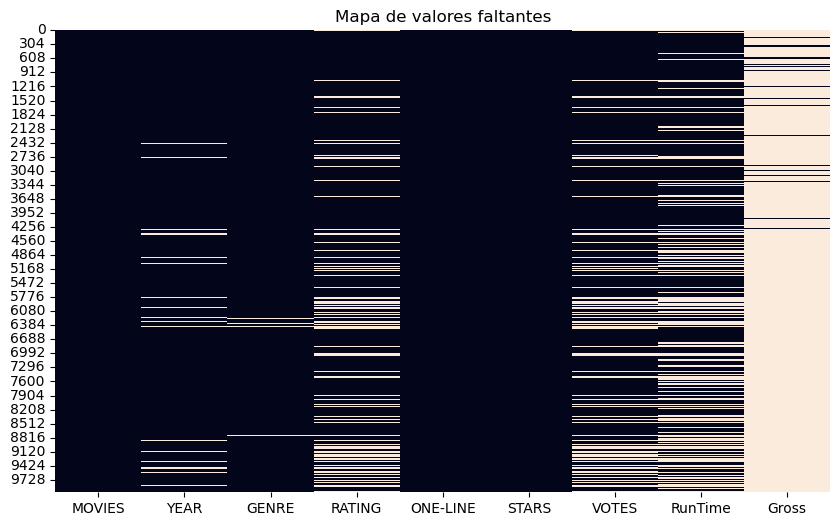

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores faltantes")
plt.show()

Como podemos observar la columna Gross tiene demasiados valores faltantes, por lo que procederemos a eliminarla ya que sabemos que los valores faltantes para un modelo no son provechosos

In [10]:
df = df.drop(columns=["Gross"])

Luego vamos a rellenar valores, primero con los numericos los vamos a rellenar con la media 

In [11]:
df["RunTime"] = df["RunTime"].fillna(df["RunTime"].mean())

Luego los categoricos con "Uknown"

In [12]:
df["GENRE"] = df["GENRE"].fillna("Unknown")
df["STARS"] = df["STARS"].fillna("Unknown")

Verificamos

In [13]:
df.isnull().sum()

MOVIES         0
YEAR         644
GENRE          0
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime        0
dtype: int64

Se realizó una verificación de valores faltantes mediante el método isnull().sum(). Posteriormente, se aplicaron estrategias de tratamiento como eliminación de columnas con alto porcentaje de datos faltantes y reemplazo de valores nulos en variables numéricas con la media y en variables categóricas con la categoría "Unknown". Finalmente, se comprobó que el dataset redujo mucho su porcentaje de valores nulos 

** MANIPULACION DE FILAS Y COLUMNAS **

Renombrar columnas

In [15]:
df = df.rename(columns={
    "MOVIES": "Movie",
    "YEAR": "Year",
    "GENRE": "Genre",
    "RATING": "Rating",
    "ONE-LINE": "OneLine",
    "STARS"  : "Stars",      
    "VOTES"  : "Votes"
   
})

** MANEJO DE DUPLICADOS **

In [16]:
df.duplicated().sum()

np.int64(431)

eliminamos duplicados 

In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.columns

Index(['Movie', 'Year', 'Genre', 'Rating', 'OneLine', 'Stars', 'Votes',
       'RunTime'],
      dtype='object')

In [25]:
df.columns = df.columns.str.strip().str.lower().str.replace("-", "_")

In [26]:
df.columns

Index(['movie', 'year', 'genre', 'rating', 'oneline', 'stars', 'votes',
       'runtime'],
      dtype='object')

In [27]:
import re

text_columns = ["movie", "genre", "oneline", "stars"]

for col in text_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .apply(lambda x: re.sub(r"[^a-zA-Z0-9\s]", "", x))
        .str.replace("add a plot", "", regex=False)
    )

In [28]:
df.head()

,movie,year,genre,rating,oneline,stars,votes,runtime
0,blood red sky,(2021),action horror thriller,6.1,a woman with a mysterious illness is forced in...,director\npeter thorwarth\n \n stars\nperi ...,"21,062",121.000000
1,masters of the universe revelation,(2021– ),animation action adventure,5.0,the war for eternia begins again in what may b...,stars\nchris wood \nsarah michelle gellar \nle...,"17,870",25.000000
2,the walking dead,(2010–2022),drama horror thriller,8.2,sheriff deputy rick grimes wakes up from a com...,stars\nandrew lincoln \nnorman reedus \nmeliss...,"885,805",44.000000
3,rick and morty,(2013– ),animation adventure comedy,9.2,an animated series that follows the exploits o...,stars\njustin roiland \nchris parnell \nspence...,"414,849",23.000000
4,army of thieves,(2021),action crime horror,NaN,a prequel set before the events of army of the...,director\nmatthias schweighfer\n \n stars\n...,NaN,68.688539


Se realizó un proceso de limpieza y normalización del texto en las variables categóricas del conjunto de datos (movie, genre, oneline, stars). Primero, se estandarizaron los nombres de las columnas para garantizar consistencia. Posteriormente, se eliminaron espacios innecesarios, se transformó todo el texto a minúsculas y se removieron caracteres especiales mediante expresiones regulares. Además, se eliminaron textos irrelevantes como “add a plot”. Este proceso permitió mejorar la calidad y coherencia de los datos, facilitando su uso en análisis posteriores y en posibles modelos de Inteligencia Artificial.

** CONSISTENCIA Y VALIDACION LOGICA DEL CONJUNTO DE DATOS **

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9568 entries, 0 to 9998
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movie    9568 non-null   object 
 1   year     9026 non-null   object 
 2   genre    9568 non-null   object 
 3   rating   8168 non-null   float64
 4   oneline  9568 non-null   object 
 5   stars    9568 non-null   object 
 6   votes    8168 non-null   object 
 7   runtime  9568 non-null   float64
dtypes: float64(2), object(6)
memory usage: 672.8+ KB


Inconsistencias detectadas

1. votes está como object, hay que cambiarlo, debe convertirse a numerico 

In [30]:
df["votes"] = df["votes"].str.replace(",", "")
df["votes"] = pd.to_numeric(df["votes"], errors="coerce")

In [31]:
df["votes"].dtype

dtype('float64')

2. rating tiene valores faltantes

In [34]:
df["rating"].isnull().sum()

np.int64(0)

3. year tiene valores faltantes y es tipo object

In [35]:
df["year"].unique()[:20]

array(['(2021)', '(2021– )', '(2010–2022)', '(2013– )', '(2020– )',
       '(2006–2013)', '(2019– )', '(2016–2021)', '(2011– )', '(2005– )',
       '(2008–2013)', '(2017– )', '(2017–2021)', '(2016– )',
       '(1994–2004)', '(2014– )', '(2013–2020)', '(2015– )',
       '(2005–2020)', '(2013–2022)'], dtype=object)

In [36]:
df["year"] = df["year"].str.extract(r"(\d{4})")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9568 entries, 0 to 9998
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movie    9568 non-null   object 
 1   year     8933 non-null   float64
 2   genre    9568 non-null   object 
 3   rating   9568 non-null   float64
 4   oneline  9568 non-null   object 
 5   stars    9568 non-null   object 
 6   votes    8168 non-null   float64
 7   runtime  9568 non-null   float64
dtypes: float64(4), object(4)
memory usage: 672.8+ KB


Se realizó una verificación estructural del dataset utilizando el método info(). Se identificó que las variables rating y year presentan valores faltantes. Asimismo, la variable votes se encontraba almacenada como tipo texto (object), lo cual no es consistente con su naturaleza numérica. Por lo tanto, se procedió a convertir dicha variable a formato numérico y a evaluar estrategias de tratamiento para los valores nulos. Este proceso permitió asegurar la coherencia estructural y lógica del conjunto de datos antes de su análisis posterior.

** FILTRADO **

Eliminar runtime menor o igual a 0

In [38]:
df = df[df["runtime"] > 0]

Eliminar votos negativos si es que existen 

In [39]:
df = df[df["votes"] >= 0]

se aplicaron filtros lógicos eliminando registros con valores inválidos o faltantes en variables clave como rating y votes. Estas acciones aseguraron la consistencia y calidad del conjunto de datos previo al análisis.

** OPERACIONES DE AGREGACION Y AGRUPAMIENTO **

Promedio de rating por género

In [40]:
df.groupby("genre")["rating"].mean().sort_values(ascending=False).head(10)

genre
crime mystery romance            8.800
family talkshow                  8.700
short                            8.675
documentary short scifi          8.600
adventure comedy realitytv       8.600
documentary realitytv romance    8.500
comedy crime romance             8.500
family music                     8.400
comedy news talkshow             8.300
animation comedy musical         8.300
Name: rating, dtype: float64

Cantidad de películas por año

In [41]:
df.groupby("year")["movie"].count().sort_values(ascending=False)

year
2020.0    1521
2019.0    1291
2018.0    1045
2017.0     811
2021.0     684
          ... 
1957.0       1
1961.0       1
1967.0       1
1971.0       1
1972.0       1
Name: movie, Length: 76, dtype: int64

Promedio de rating por año

In [42]:
df.groupby("year")["rating"].mean().sort_values(ascending=False)

year
1962.0    8.300000
1972.0    8.200000
1992.0    8.120000
1968.0    8.100000
1989.0    8.033333
            ...   
1967.0    6.000000
1944.0    5.900000
1933.0    5.400000
1938.0    5.200000
1973.0    5.033333
Name: rating, Length: 76, dtype: float64

Verificar resultados

In [43]:
df.groupby("genre")["rating"].mean().round(2)

genre
action                        5.10
action adventure              5.23
action adventure biography    7.72
action adventure comedy       6.77
action adventure crime        6.27
                              ... 
talkshow                      6.85
thriller                      5.16
unknown                       6.56
war                           8.20
western                       6.56
Name: rating, Length: 485, dtype: float64

** CONCLUSIONES **

Durante la limpieza y preparación del conjunto de datos encontramos varios problemas que podían afectar el análisis y la construcción de modelos de inteligencia artificial. Por ejemplo, había valores faltantes en variables importantes como rating y year, y la columna votes estaba guardada como texto en lugar de números.

Para solucionarlo, estandarizamos los nombres de las columnas, normalizamos el texto en las variables categóricas (pasándolo todo a minúsculas, quitando caracteres especiales y espacios de más) y eliminamos registros duplicados. También convertimos los tipos de datos para que las variables numéricas quedaran bien formateadas y aplicamos validaciones lógicas para asegurarnos de que los valores estuvieran dentro de rangos coherentes.

----------------------------------------------------------------------------------------

1.2. EDA y transformacion de columnas

** MEDIDAS DE TENDENCIA CENTRAL **

In [44]:
df[["rating", "votes", "runtime", "year"]].describe()

,rating,votes,runtime,year
count,8168.000000,8.168000e+03,8168.000000,8168.000000
mean,6.919699,1.514441e+04,69.326954,2015.832762
std,1.219970,7.009954e+04,43.280477,7.569987
min,1.100000,5.000000e+00,1.000000,1932.000000
25%,6.200000,1.670000e+02,42.000000,2015.000000
50%,7.100000,7.925000e+02,68.688539,2018.000000
75%,7.800000,3.780750e+03,90.000000,2020.000000
max,9.900000,1.713028e+06,853.000000,2021.000000


¿Como interpretamos estos resultados?
1. Rating
Media: 6.92
Mediana: 7.10
Mínimo: 1.1
Máximo: 9.9
Interpretación:
La media y la mediana son muy cercanas = distribución relativamente equilibrada.
La mayoría de películas tienen calificaciones aceptables.
Hay pocos valores muy bajos (1.1), pero no afectan demasiado la media.

2. Votes
Media: 15,144
Mediana: 792
Máximo: 1,713,028
Interpretación:
Hay una GRAN diferencia entre media y mediana.
Existen películas extremadamente populares que elevan la media.

3. Runtime
Media: 69.3 minutos
Mediana: 68.7 minutos
Máximo: 853 minutos
Interpretación:
Media y mediana casi iguales = distribución bastante estable.
El valor máximo (853 minutos) parece extremo y podría ser un caso especial (serie, documental largo, error).

4. Year
Media: 2015.83
Mediana: 2018
Mínimo: 1932
Máximo: 2021
Interpretación:
La mediana (2018) es mayor que la media 
El dataset está compuesto principalmente por producciones modernas.


** MEDIDAS DE DISPERSION **

Desviacion estandar

In [45]:
df[["rating", "votes", "runtime", "year"]].std()

rating         1.219970
votes      70099.542612
runtime       43.280477
year           7.569987
dtype: float64

Varianza

In [46]:
df[["rating", "votes", "runtime", "year"]].var()

rating     1.488326e+00
votes      4.913946e+09
runtime    1.873200e+03
year       5.730471e+01
dtype: float64

Rango (máximo - mínimo)

In [47]:
df[["rating", "votes", "runtime", "year"]].max() - df[["rating", "votes", "runtime", "year"]].min()

rating           8.8
votes      1713023.0
runtime        852.0
year            89.0
dtype: float64

¿Como interpretamos estos datos?
1. Rating

Desviación estándar ≈ 1.22
Baja dispersión → la mayoría de ratings están cerca del promedio.

2. Votes
Desviación estándar ≈ 70,099
Altísima dispersión → hay valores extremadamente grandes.
Esto confirma presencia de outliers.

3. Runtime

Desviación estándar ≈ 43
Dispersión moderada.
El valor máximo de 853 minutos sugiere posibles casos atípicos.

4. Year
Desviación estándar ≈ 7.57
Baja dispersión → la mayoría de películas son de años cercanos (producciones recientes).

** MEDIDAS DE POSICION **

Cálculo de Cuartiles

In [49]:
df[["rating", "votes", "runtime", "year"]].quantile([0.25, 0.5, 0.75])

,rating,votes,runtime,year
0.25,6.2,167.00,42.000000,2015.0
0.50,7.1,792.50,68.688539,2018.0
0.75,7.8,3780.75,90.000000,2020.0


Cálculo del IQR (Q3-Q1)

In [50]:
Q1 = df[["rating", "votes", "runtime", "year"]].quantile(0.25)
Q3 = df[["rating", "votes", "runtime", "year"]].quantile(0.75)

IQR = Q3 - Q1
IQR

rating        1.60
votes      3613.75
runtime      48.00
year          5.00
dtype: float64

In [52]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Identificar registros con outliers

In [53]:
outliers = df[
    ((df[["rating", "votes", "runtime", "year"]] < lower_bound) |
     (df[["rating", "votes", "runtime", "year"]] > upper_bound))
    .any(axis=1)
]

outliers.shape

(1991, 8)

In [54]:
runtime_outliers = df[
    (df["runtime"] < lower_bound["runtime"]) |
    (df["runtime"] > upper_bound["runtime"])
]

runtime_outliers.shape

(131, 8)

In [55]:
df_clean = df[
    (df["runtime"] >= lower_bound["runtime"]) &
    (df["runtime"] <= upper_bound["runtime"])
]

df_clean.shape

(8037, 8)

Tras aplicar el método del rango intercuartílico (IQR) a la variable runtime, se identificaron 131 registros con valores atípicos extremos. Por lo que su eliminación no afecta la representatividad de la muestra. La depuración permitió reducir la influencia de valores atipicos que podrían distorsionar las medidas estadísticas y análisis posteriores.

** HISTOGRAMA **

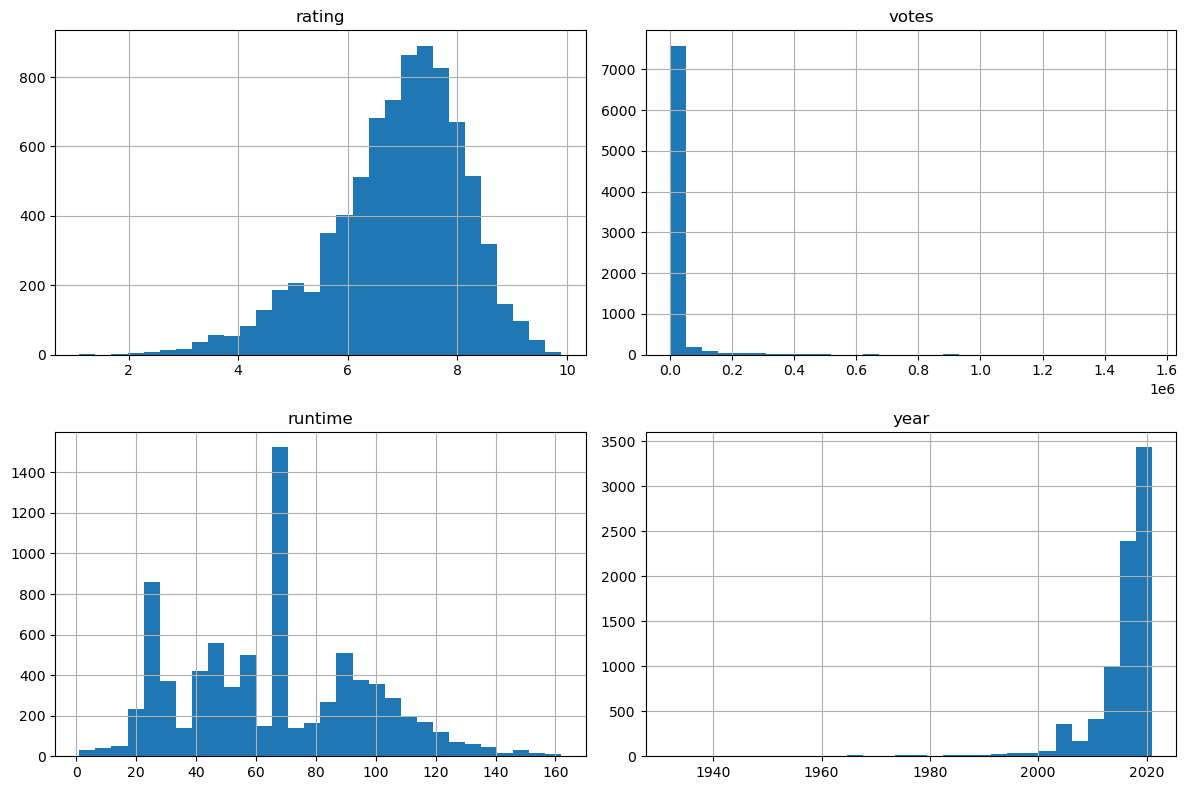

In [57]:
import matplotlib.pyplot as plt

numeric_cols = ["rating", "votes", "runtime", "year"]

df_clean[numeric_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

Histograma con transformación log en votes

C:\Users\simon\AppData\Local\Temp\ipykernel_15852\2571823228.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["votes_log"] = np.log1p(df_clean["votes"])


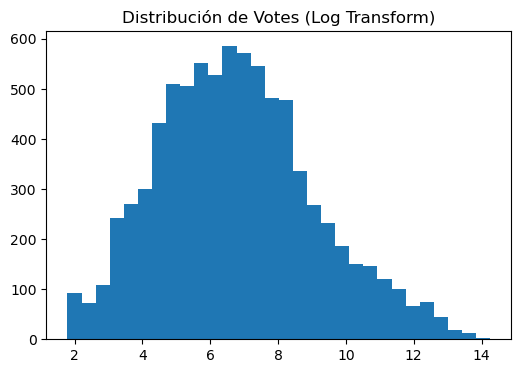

In [58]:
import numpy as np
df_clean["votes_log"] = np.log1p(df_clean["votes"])
plt.figure(figsize=(6,4))
plt.hist(df_clean["votes_log"], bins=30)
plt.title("Distribución de Votes (Log Transform)")
plt.show()

La variable votes presentó una fuerte asimetría positiva debido a la presencia de producciones extremadamente populares. Para reducir esta distorsión y mejorar la interpretación visual y estadística, se aplicó una transformación logarítmica, obteniendo una distribución más equilibrada y adecuada para análisis posteriores.

** GRAFICOS DE DISPERSION ENTRE DOS COLUMNAS **

Rating vs Votes (log)

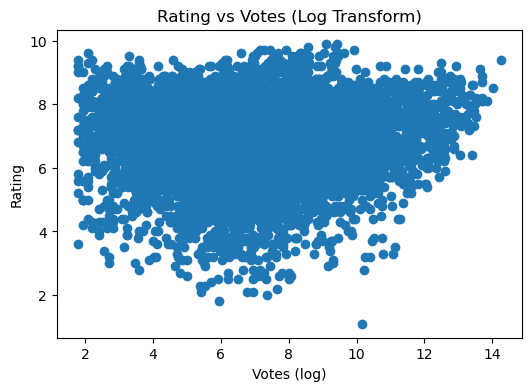

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df_clean["votes_log"], df_clean["rating"])
plt.xlabel("Votes (log)")
plt.ylabel("Rating")
plt.title("Rating vs Votes (Log Transform)")
plt.show()

Rating vs Runtime

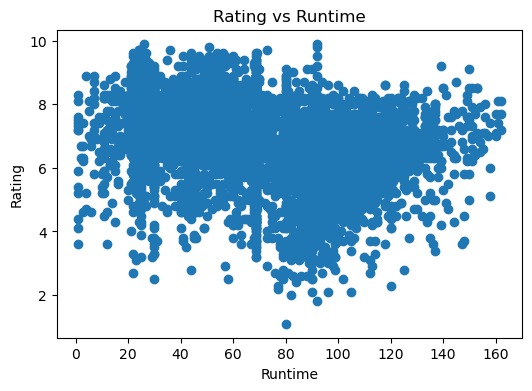

In [60]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean["runtime"], df_clean["rating"])
plt.xlabel("Runtime")
plt.ylabel("Rating")
plt.title("Rating vs Runtime")
plt.show()

Rating vs Year

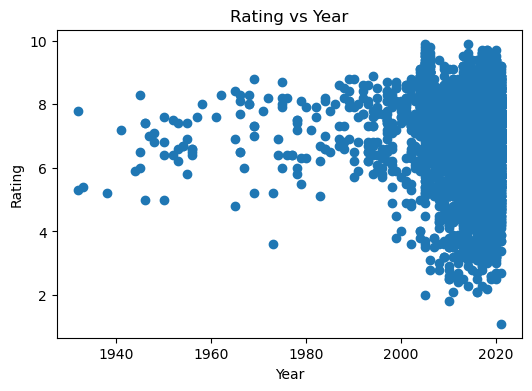

In [61]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean["year"], df_clean["rating"])
plt.xlabel("Year")
plt.ylabel("Rating")
plt.title("Rating vs Year")
plt.show()

Calcular correlacion 

In [62]:
df_clean[["rating", "votes_log", "runtime", "year"]].corr()

,rating,votes_log,runtime,year
rating,1.000000,0.023659,-0.35352,-0.027446
votes_log,0.023659,1.000000,0.27640,-0.196091
runtime,-0.353520,0.276400,1.00000,-0.069170
year,-0.027446,-0.196091,-0.06917,1.000000


¿Como interpretar esta tabla?

1. Rating vs Votes_log

0.0237 Correlación prácticamente nula.

Interpretación:
No hay relación lineal significativa entre popularidad y calificación.
Tener más votos NO implica necesariamente mejor rating.
Esto es interesante porque contradice lo que muchas personas suponen.

2. Rating vs Runtime

-0.3535 Correlación negativa moderada.

Interpretación:
Películas más largas tienden a tener ligeramente menor rating.
No es una relación fuerte, pero sí apreciable.
Puede indicar que películas demasiado largas no son tan bien valoradas.


3. Rating vs Year

-0.0274 Correlación casi nula.

Interpretación:
Las películas recientes no tienen mejores ni peores ratings en promedio.
No hay tendencia clara en el tiempo.
